In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib as mpl

import seaborn as sns
from matplotlib import colormaps as cm
from matplotlib.ticker import LogFormatter 

### Preparation

##### Set Labels and Colors for CDR methods, MRV topics, and research methods

In [6]:
cdr_method_colors = {
    
    'SCS': '#a47551', 
    
    'A/R': '#238b45', 
    'General forestry': '#66c2a4', 
    'Agroforestry': '#b2e2e2', 
    'Forest management': '#edf8fb',

    'Biochar': '#ce1256',
    'Restoration of landscapes and peats': '#df65b0',
    'EW': '#d7b5d8', 
  
    'OAE': '#016c59', 
    'OIF/AU': '#1c9099', 
    'DOC': '#67a9cf',
    'Algae ': '#bdc9e1', 
    'Blue carbon': '#f6eff7',
       
    'CCS': '#e31a1c',
    'BECCS': '#fd8d3c', 
    'DACCS': '#fecc5c',
    'CCUS': '#ffffb2', 
    
    'General CDR': '#525252', 
    'Other': '#969696',    
}

# Define the custom color scheme for each CDR group
cdr_group_colors = {
    "SCS": '#C1A28A' ,            # brown for SCS
    "Forestry": '#8fbc8f',         # green for Forestry
    "Terrestrial CDR": '#df65b0',  # green for Terrestrial CDR
 
    "Marine CDR": '#7eaed3',    # bluew for Marine CDR
    "CCS": '#ff7f00',            # orange for CCS
    "General CDR/Other": '#e5e5e5', # grey for General/Other
}  

mrv_topic_colors = {
    'Quantification': '#7da7b8',   # darker bluish-grey
    'Monitoring': '#8dc39f',        # stronger soft green
    'Quality': '#c76a85',           # berry red
    'Governance': '#b39bc8',        # stronger lavender
    'Reporting': '#e1a6b8',         # stronger soft pink
    'Verification': '#a8a8a8',      # medium grey
    'External Impacts': '#d0c97b',   # stronger soft yellow
    'General MRV': '#e5b138',      # muted yellow
    
}

cdr_method_label = \
{
    'SCS': "Soil Carbon Sequestration",
    'A/R': "Afforestation/Reforestation",
    'General forestry': "General Forestry",
    'Agroforestry': "Agroforestry",
    'Forest management': "Forest Management",
    'Biochar': "Biochar",
    'Restoration of landscapes and peats': "Restoration of \nLandscapes/Peats",
    'EW': "Enhanced Weathering",
    'OAE': "Ocean Alkalinity \nEnhancement",
    'OIF/AU': "Ocean Iron Fertilization", 
    'DOC':"Direct Ocean Capture",
    'Algae ':"Algae",
    'Blue carbon': "Blue Carbon",
    'CCS':"CCS",
    'BECCS':"BECCS",
    'DACCS':"DACCS",
    'CCUS':"CCUS",
    'General CDR':"General CDR",
    'Other':"Other"
}      

cpool_label = \
{
    'SOC / SOC Proxy': "SOC/SOC Proxy",
    'SIC': "SIC",
    'BGB': "BGB", 
    'AGB / AGB Proxy': "AGB/AGB Proxy",
    'Litter': "Litter", 
    'Harvested Wood Products': "Harvested Wood Products",
    'Biochar stability in soil': "Biochar Stability in Soil",
    'Biochar Carbon content': "Biochar Carbon Content",
    'Carbonate alkalinity': "Carbonate Alkalinity",
    'Marine Biomass': "Marine Biomass",
    'Capture process': "Capture Process",
    'Geological storage': "Geological Storage",
    'All carbon pools': "All Carbon Pools",
    'no information': "No Information"
}

mtool_label = \
{
    'Allometric equations': "Allometric Equations",
    'Field Sampling': "Field Sampling/Measurement",
    'Laboratory analysis': "Laboratory Analysis",
    'Modelling': "Modeling",
    'Remote Sensing': "Remote Sensing",
    'no information': "No Information",
}

resMethod_colors = {
     'Modelling':'#e34a33',
     'Data analysis/Statistical analysis/Econometric':'#fdbb84',
     'Remote sensing':'#253494',
     'Experiment - Field study':'#2c7fb8',
     'Experiment - Laboratory experiment':'#41b6c4',
     'Qualitative research':'#31a354'
}

##### Group CDR methods

In [7]:
cdr_group_mapping = {
     # Marine CDR group
    "OIF/AU":"Marine CDR",
    "Blue carbon": "Marine CDR",
    "OAE": "Marine CDR",
    "DOC": "Marine CDR",
    "Algae ": "Marine CDR",
    
    # Terrestrial CDR group
    "EW": "Terrestrial CDR",
    "Biochar": "Terrestrial CDR",
    "Restoration of landscapes and peats": "Terrestrial CDR",
    
    # CCS group
    "DACCS": "CCS",
    "BECCS": "CCS",
    "CCUS": "CCS",
    "CCS": "CCS",
    
    # General CDR/Other group
    "General CDR": "General CDR/Other",
    "Other": "General CDR/Other",

    # SCS
    "SCS": "SCS",

    # Forestry
    "General forestry": "Forestry",
    "A/R": "Forestry",
    "Agroforestry": "Forestry",
    "Forest management": "Forestry",
}

### Get and clean data

In [14]:
df = pd.read_excel("MRVdata_1308.xlsx", sheet_name="CodingCompleted_withoutLCA") 
df_filtered = df[df['Year'] != 2024]
df_included = df_filtered[df_filtered['Inclusion/exclusion'] == 'Inclusion'].copy() # new dataframe defined to exclude studies without access or excluded papers

### additonal data

def extract_CDR_method_focus(row):
    CDR_method = []
    CDR_focus = []
    
    for column in cdr_method_colors.keys():  # previously defined list with columns that contain CDR methods
        if row[column] > 0:
            CDR_method.append(column)
            CDR_focus.append(row[column])
    
    return [CDR_method, CDR_focus]
# add new columns to the data frame
df_included['CDR_focus'] = df_included.apply(lambda row: extract_CDR_method_focus(row), axis=1)
df_included['CDR_method'] = df_included.CDR_focus.str[0]
df_included['CDR_focus'] = df_included.CDR_focus.str[1]


#add new column for MRV topic and study focus to the dataset
def extract_MRV_topic_focus(row):
    MRV_topic = []
    MRV_focus = []
    
    for column in mrv_topic_colors.keys():  # previously defined list with columns that contain MRV topics
        if row[column] > 0:
            MRV_topic.append(column)
            MRV_focus.append(row[column])
    
    return [MRV_topic, MRV_focus]
# add new columns to the data frame
df_included['MRV_focus'] = df_included.apply(lambda row: extract_MRV_topic_focus(row), axis=1)
df_included['MRV_topic'] = df_included.MRV_focus.str[0]
df_included['MRV_focus'] = df_included.MRV_focus.str[1]


### explode
# explode CDR method and focus
df_CDRexplode = df_included.explode(['CDR_method', 'CDR_focus'])

# explode MRV topic and focus
df_MRVexplode = df_included.explode(['MRV_topic', 'MRV_focus'])

### create larger groups
# Create a new column ‘CDR_group’ in df_exploded based on the ‘CDR_method’ column
df_CDRexplode['CDR_group'] = df_CDRexplode['CDR_method'].map(cdr_group_mapping)


In [15]:
df_quant = df_MRVexplode.loc[df_MRVexplode.MRV_topic.isin(["Quantification"])]
df_quant = df_quant.explode("CDR_method")

### Panel A: All CDR methods vs Carbon Pool

In [16]:
df_quant["cpool_list"] = df_quant['Point of measurement/carbon pool'].str.split(', ')
df_cpool = df_quant.explode("cpool_list")
df_cpool["cpool_norm"] = df_cpool["cpool_list"].str.split(' \(').str[0]
repl = {
    "AGB": "AGB / AGB Proxy",
    "AGB Proxy": "AGB / AGB Proxy",
    "SOC": "SOC / SOC Proxy",
    "SOC Proxy": "SOC / SOC Proxy",

}
df_cpool["cpool_norm"] = df_cpool["cpool_norm"].replace(repl)

method_list = [
    'SOC / SOC Proxy',
    'SIC', 'BGB', 
    'AGB / AGB Proxy',
    'Litter',
    'Harvested Wood Products',
    'Biochar stability in soil',
    'Biochar Carbon content',
    'Carbonate alkalinity', 
    'Marine Biomass',
    'Capture process',
    'Geological storage',
    'All carbon pools',
    'no information',     
]

<>:3: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\('
C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\3568983523.py:3: SyntaxWarning: invalid escape sequence '\('
  df_cpool["cpool_norm"] = df_cpool["cpool_list"].str.split(' \(').str[0]


In [17]:
# creating heatmap
hm1 = df_cpool.groupby(["CDR_method","cpool_norm"], as_index=False).size()
hm1 = hm1.pivot(index="CDR_method",columns="cpool_norm",values="size")
# sorting
hm1 = hm1[method_list]
hm1 = hm1.reindex(cdr_method_label.keys())
#hm1 = hm1.reindex(cpool_label.keys())

hm1.fillna(0, inplace=True)
hm1_abs = hm1.copy()

# adding total counts
counts1_x = hm1.sum(axis=1)
hm1["Total Count"] = hm1.sum(axis=1)


# calculating research counts
counts1_y = hm1.sum()
counts1_y_df = {}
for i,c in enumerate(hm1.columns):
    counts1_y_df[c] = [counts1_y[i]]

# calculating relative numbers
hm1[hm1.columns[:-1]] = hm1[hm1.columns[:-1]].div(hm1["Total Count"],axis=0)*100

# adding last row (absolute numbers of research counts)
hm1 = pd.concat([hm1, pd.DataFrame(counts1_y_df)])
hm1.index = hm1.index[:-1].tolist()+["Total Count"]

C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\3843204587.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts1_y_df[c] = [counts1_y[i]]


C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\1712216263.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(len(hm1.columns)-0.5, i+0.5, str(int(counts1_x[i])),
C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\1712216263.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i+0.5, len(hm1)-.5, str(int(counts1_y[i])),


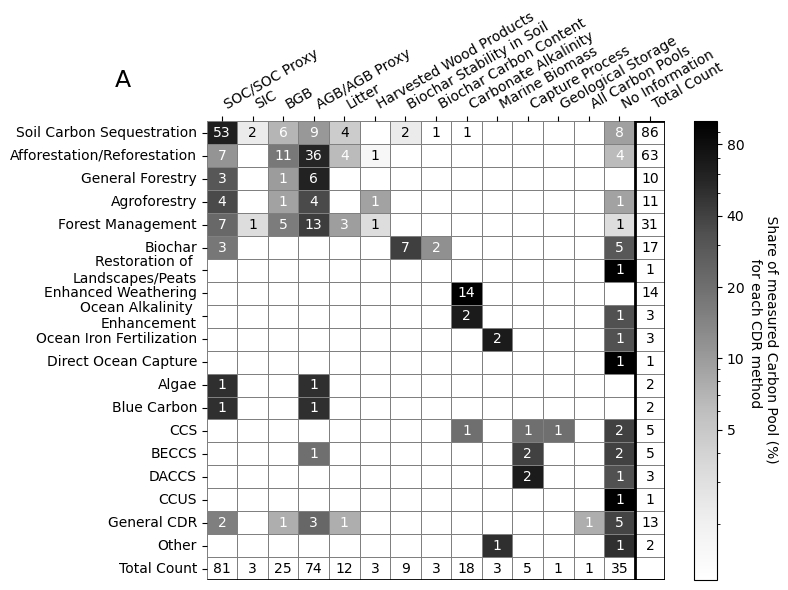

In [18]:
fig=plt.figure(figsize=(8, 6))

# define which areas are not used in the plot
mask1 = np.zeros_like(hm1)
mask1[-1,:] = True
mask1[:,-1] = True
mask1[-1,-1] = True

ax = sns.heatmap(data=hm1, annot=False, norm=mpl.colors.LogNorm(), cmap='Greys', mask=mask1, 
                 linecolor='grey', linewidths=0.5, 
                 cbar=False, annot_kws={"fontsize":10}, fmt='.0f')


# add the total number in the total column 
for i in range(len(hm1.index)-1):
    ax.text(len(hm1.columns)-0.5, i+0.5, str(int(counts1_x[i])), 
            ha='center', va='center', color='black', fontsize =10)

# add the total number in the total row
for i in range(len(hm1.columns)-1):
    ax.text(i+0.5, len(hm1)-.5, str(int(counts1_y[i])), 
            ha='center', va='center', color='black', fontsize =10)
# add box on last column
ax.add_patch(plt.Rectangle((len(hm1.columns)-1, 0), 1, 
                           len(hm1.index), fill=None, ec='black', linewidth=2, alpha=1))
# add box on last row
ax.add_patch(plt.Rectangle((0, len(hm1.index)), 
                           len(hm1.columns), len(hm1.index), fill=None, ec='black', 
                           linewidth=2, alpha=1))

# add absolute numbers into cells
for c in range(len(hm1.columns)-1):
    for r in range(len(hm1.index)-1):
        if hm1_abs.iloc[r,c]==0 or hm1.iloc[r,c]>6:
            col = "white"
        else:
            col = "black"
        text = str(int(hm1_abs.iloc[r,c]))
        ax.text(c+0.5, r+0.5, text, ha='center', va='center', color=col, fontsize =10)

# handle log-scale on colorbar
formatter = LogFormatter(2, labelOnlyBase=False)
mappable = ax.collections[0]
cb = plt.colorbar(mappable= mappable, ticks=[1,5,10,20,40,80], format=formatter)

# Create labels, legend and colors
#_ = ax.set_xticks([i+.5 for i in range(6)],["Modelling", "Data Analysis", "Remote Sensing", "Field Study", "Laboratory Experiment", "Qualitative"])
_ = ax.tick_params(axis='x', labelbottom=False, labeltop=True, top=True, bottom=False)
#_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='left', fontsize = 10)
_ = ax.set_xticklabels([cpool_label.get(label, label) for label in hm1.columns], rotation=30, ha='left', fontsize = 10)
_ = ax.set_yticklabels([cdr_method_label.get(label, label) for label in hm1.index], fontsize=10)
_ = plt.text(18.2,14.8, "       Share of measured Carbon Pool (%)\n    for each CDR method", rotation=270, ha="center")

plt.text(-3, -1.5, "A", fontsize=17)

fig.tight_layout()

### Panel B: All scientific methods vs Carbon Pool

In [19]:
df_cpool["Measurement tool_broad"] = df_cpool["Measurement tool"].apply(lambda x: x.split(' (')[0])

def text_cleaning(x):
    return (
        x.replace("FIeld","Field")\
         .replace("allo","Allo")\
         .replace("sampl","Sampl")\
         .replace("measurements", "Measurement") \
         .replace("measurement", "Measurement") \
         .replace("Measurement","Sampling") #?
         .replace("Modelling ", "Modelling")
    )
    


df_cpool["Measurement tool_broad"] = df_cpool["Measurement tool_broad"].apply(text_cleaning)
df_cpool["Measurement tool_broad_list"] = df_cpool["Measurement tool_broad"].str.split(', ')
df_cpool_exTool = df_cpool.explode("Measurement tool_broad_list")

In [25]:
df_cpool_exTool.drop_duplicates(subset=['Title',"Measurement tool_broad_list", "cpool_norm"], inplace=True)

In [21]:
# creating heatmap
hm2 = df_cpool_exTool.groupby(["Measurement tool_broad_list","cpool_norm"], as_index=False).size()
hm2 = hm2.pivot(index="cpool_norm",columns="Measurement tool_broad_list",values="size")
hm2.fillna(0, inplace=True)

# sorting
hm2 = hm2.reindex(method_list)
#hm2 = hm2.reindex(

hm2_abs = hm2.copy()

# adding total counts
counts2_x = hm2.sum(axis=1)
hm2["Total Count"] = hm2.sum(axis=1)


# calculating research counts
counts2_y = hm2.sum()
counts2_y_df = {}
for i,c in enumerate(hm2.columns):
    counts2_y_df[c] = [counts2_y[i]]

# calculating relative numbers
hm2[hm2.columns[:-1]] = hm2[hm2.columns[:-1]].div(hm2["Total Count"],axis=0)*100

# adding last row (absolute numbers of research counts)
hm2 = pd.concat([hm2, pd.DataFrame(counts2_y_df)])
hm2.index = hm2.index[:-1].tolist()+["Total Count"]

C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\1067580917.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts2_y_df[c] = [counts2_y[i]]


C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\1505106520.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(len(hm2.columns)-0.5, i+0.5, str(int(counts2_x[i])), ha='center',
C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\1505106520.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i+0.5, len(hm2)-.5, str(int(counts2_y[i])), ha='center',


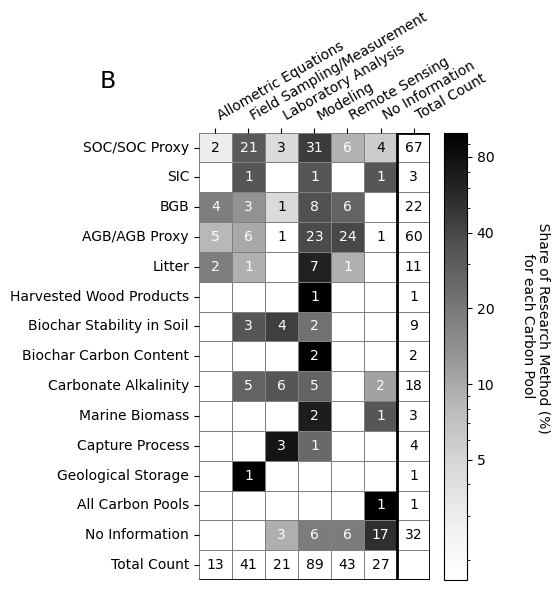

In [22]:
fig=plt.figure(figsize=(6, 6))

# define which areas are not used in the plot
mask2 = np.zeros_like(hm2)
mask2[-1,:] = True
mask2[:,-1] = True
mask2[-1,-1] = True

ax = sns.heatmap(data=hm2, annot=False, norm=mpl.colors.LogNorm(), cmap='Greys', mask=mask2, 
                 linecolor='grey', linewidths=0.5, 
                 cbar=False, annot_kws={"fontsize":10}, fmt='.0f')


# add the total number in the total column 
for i in range(len(hm2.index)-1):
    ax.text(len(hm2.columns)-0.5, i+0.5, str(int(counts2_x[i])), ha='center', 
            va='center', color='black', fontsize =10)

# add the total number in the total row
for i in range(len(hm2.columns)-1):
    ax.text(i+0.5, len(hm2)-.5, str(int(counts2_y[i])), ha='center', 
            va='center', color='black', fontsize =10)
# add box on last column
ax.add_patch(plt.Rectangle((len(hm2.columns)-1, 0), 1, len(hm2.index), 
                           fill=None, ec='black', linewidth=2, alpha=1))
# add box on last row
ax.add_patch(plt.Rectangle((0, len(hm2.index)), len(hm2.columns), len(hm2.index), 
                           fill=None, ec='black', linewidth=2, alpha=1))

# add absolute numbers into cells
for c in range(len(hm2.columns)-1):
    for r in range(len(hm2.index)-1):
        if hm2_abs.iloc[r,c]==0 or hm2.iloc[r,c]>6:
            col = "white"
        else:
            col = "black"
        text = str(int(hm2_abs.iloc[r,c]))
        ax.text(c+0.5, r+0.5, text, ha='center', va='center', color=col, fontsize =10)

# handle log-scale on colorbar
formatter = LogFormatter(2, labelOnlyBase=False)
mappable = ax.collections[0]
cb = plt.colorbar(mappable= mappable, ticks=[1,5,10,20,40,80], format=formatter)

# Create labels, legend and colors
#_ = ax.set_xticks([i+.5 for i in range(6)],["Modelling", "Data Analysis", "Remote Sensing", "Field Study", "Laboratory Experiment", "Qualitative"])
_ = ax.tick_params(axis='x', labelbottom=False, labeltop=True, top=True, bottom=False)
#_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='left', fontsize = 10)
#_ = ax.set_yticklabels(ax.get_yticklabels(),fontsize = 10)

_ = ax.set_xticklabels([mtool_label.get(label, label) for label in hm2.columns], rotation=30, ha='left', fontsize = 10)
_ = ax.set_yticklabels([cpool_label.get(label, label) for label in hm2.index], fontsize=10)

_ = plt.text(10.2,10, "          Share of Research Method (%)\n         for each Carbon Pool", rotation=270, ha="center")

plt.text(-3, -1.5, "B", fontsize=17)

fig.tight_layout()

### All together: Final version of Figure 8

C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\2717191324.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.text(len(hm1.columns)-0.5, i+0.5, str(int(counts1_x[i])),
C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\2717191324.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.text(i+0.5, len(hm1)-.5, str(int(counts1_y[i])), ha='center',
C:\Users\leonst\AppData\Local\Temp\ipykernel_21560\2717191324.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

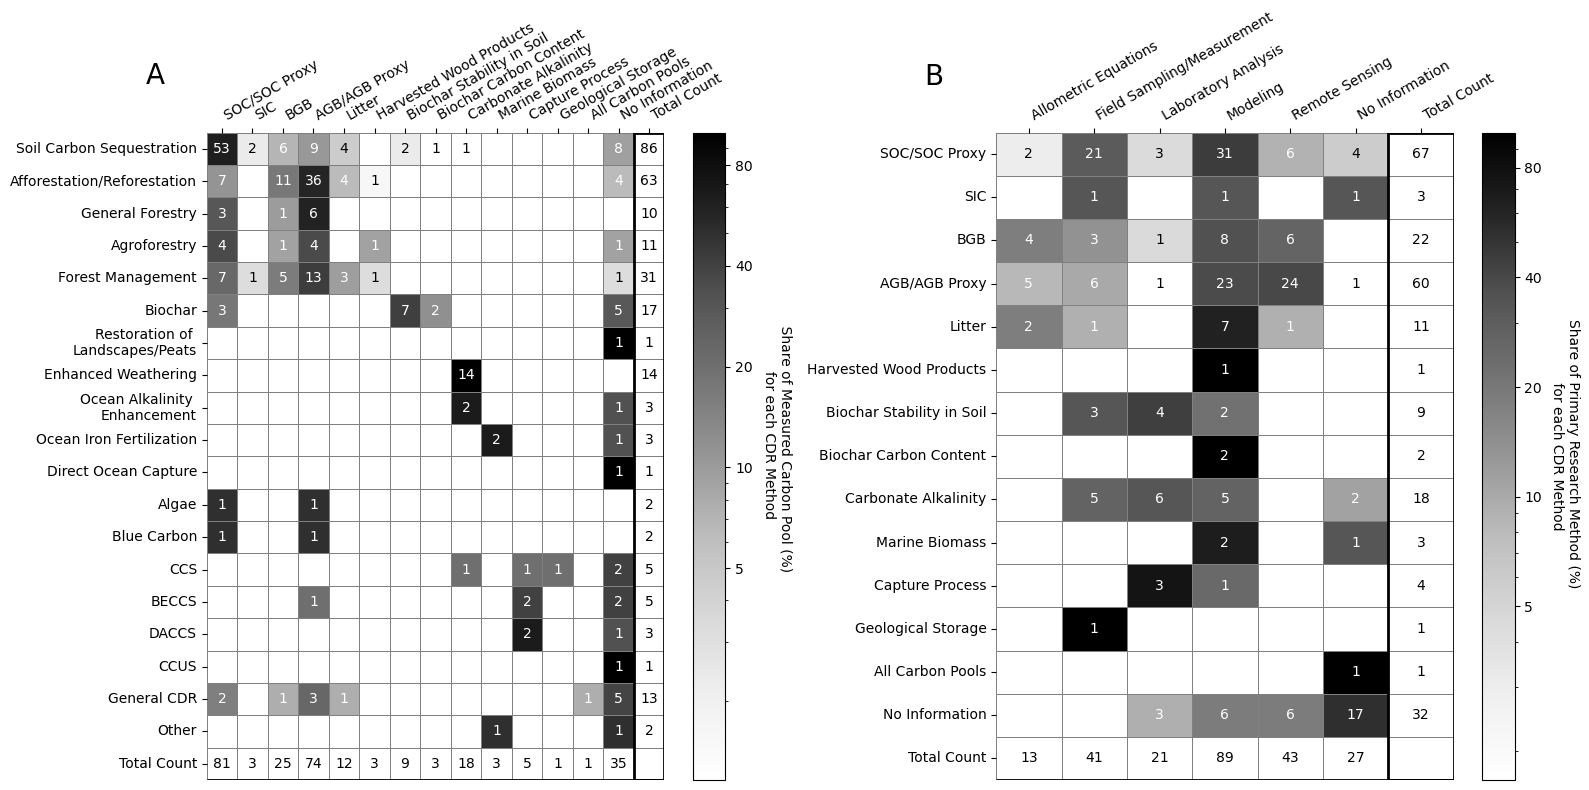

In [26]:
fig = plt.figure(figsize=(16,8))
gs = fig.add_gridspec(1,2,width_ratios=[1,1])

##### LEFT #######
ax1 = fig.add_subplot(gs[0,0])

ax1 = sns.heatmap(data=hm1, annot=False, norm=mpl.colors.LogNorm(), cmap='Greys', mask=mask1, 
                 linecolor='grey', linewidths=0.5, 
                 cbar=False, annot_kws={"fontsize":10}, fmt='.0f')


# add the total number in the total column 
for i in range(len(hm1.index)-1):
    ax1.text(len(hm1.columns)-0.5, i+0.5, str(int(counts1_x[i])), 
            ha='center', va='center', color='black', fontsize =10)

# add the total number in the total row
for i in range(len(hm1.columns)-1):
    ax1.text(i+0.5, len(hm1)-.5, str(int(counts1_y[i])), ha='center', 
            va='center', color='black', fontsize =10)
# add box on last column
ax1.add_patch(plt.Rectangle((len(hm1.columns)-1, 0), 1, len(hm1.index), 
                           fill=None, ec='black', linewidth=2, alpha=1))
# add box on last row
ax1.add_patch(plt.Rectangle((0, len(hm1.index)), len(hm1.columns), 
                           len(hm1.index), fill=None, ec='black', linewidth=2, alpha=1))

# add absolute numbers into cells
for c in range(len(hm1.columns)-1):
    for r in range(len(hm1.index)-1):
        if hm1_abs.iloc[r,c]==0 or hm1.iloc[r,c]>6:
            col = "white"
        else:
            col = "black"
        text = str(int(hm1_abs.iloc[r,c]))
        ax1.text(c+0.5, r+0.5, text, ha='center', va='center', color=col, fontsize =10)

# handle log-scale on colorbar
formatter = LogFormatter(2, labelOnlyBase=False)
mappable = ax1.collections[0]
cb = plt.colorbar(mappable= mappable, ticks=[1,5,10,20,40,80], format=formatter)

# Create labels, legend and colors
#_ = ax.set_xticks([i+.5 for i in range(6)],["Modelling", "Data Analysis", "Remote Sensing", "Field Study", "Laboratory Experiment", "Qualitative"])
_ = ax1.tick_params(axis='x', labelbottom=False, labeltop=True, top=True, bottom=False)
_ = ax1.set_xticklabels([cpool_label.get(label, label) for label in hm1.columns], rotation=30, ha='left', fontsize = 10)
_ = ax1.set_yticklabels([cdr_method_label.get(label, label) for label in hm1.index], fontsize=10)
_ = plt.text(18.7,13.5, "       Share of Measured Carbon Pool (%)\n     for each CDR Method", rotation=270, ha="center")
_ = plt.text(-2, -1.5, "A", fontsize=20)

##### RIGHT #####
ax2 = fig.add_subplot(gs[0,1])

#mask2 = hm2.isna()
ax2 = sns.heatmap(data=hm2, annot=False, norm=mpl.colors.LogNorm(), cmap='Greys', mask=mask2, 
                 linecolor='grey', linewidths=0.5, 
                 cbar=False, annot_kws={"fontsize":10}, fmt='.0f')


# add the total number in the total column 
for i in range(len(hm2.index)-1):
    ax2.text(len(hm2.columns)-0.5, i+0.5, str(int(counts2_x[i])), 
            ha='center', va='center', color='black', fontsize =10)

# add the total number in the total row
for i in range(len(hm2.columns)-1):
    ax2.text(i+0.5, len(hm2)-.5, str(int(counts2_y[i])), 
            ha='center', va='center', color='black', fontsize =10)
# add box on last column
ax2.add_patch(plt.Rectangle((len(hm2.columns)-1, 0), 1, 
                           len(hm2.index), fill=None, ec='black', linewidth=2, alpha=1))
# add box on last row
ax2.add_patch(plt.Rectangle((0, len(hm2.index)), 
                           len(hm2.columns), len(hm2.index), 
                           fill=None, ec='black', linewidth=2, alpha=1))

# add absolute numbers into cells
for c in range(len(hm2.columns)-1):
    for r in range(len(hm2.index)-1):
        if hm2_abs.iloc[r,c]==0 or hm2.iloc[r,c]>6:
            col = "white"
        else:
            col = "black"
        text = str(int(hm2_abs.iloc[r,c]))
        ax2.text(c+0.5, r+0.5, text, ha='center', va='center', color=col, fontsize =10)

# handle log-scale on colorbar
formatter = LogFormatter(2, labelOnlyBase=False)
mappable = ax2.collections[0]
cb = plt.colorbar(mappable= mappable, ticks=[1,5,10,20,40,80], format=formatter)

# Create labels, legend and colors
_ = ax2.tick_params(axis='x', labelbottom=False, labeltop=True, top=True, bottom=False)
_ = ax2.set_xticklabels([mtool_label.get(label, label) for label in hm2.columns], rotation=30, ha='left', fontsize = 10)
_ = ax2.set_yticklabels([cpool_label.get(label, label) for label in hm2.index], fontsize=10)
_ = plt.text(8.7,10.5, "Share of Primary Research Method (%)\n for each CDR Method", rotation=270, ha="center")
_ = plt.text(-1.1, -1.1, "B", fontsize=20)

fig.tight_layout()
fig.savefig("fig8_final.png")